In [1]:
# Install dependencies (run once in terminal with venv activated):
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchvision', 'tqdm', 'kagglehub', 'nltk', 'matplotlib', 'pandas', 'pillow'])


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


0

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import pandas as pd
import matplotlib.pyplot as plt
import random
import re
import os
import sys
import csv
import math
from PIL import Image
from collections import Counter
from tqdm import tqdm
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

nltk.download('punkt', quiet=True)

# MPS fallback for unsupported ops on Apple Silicon
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

# Mac-compatible device: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: mps


In [ ]:
# ── Local output directory ────────────────────────────────────────────────────
OUTPUT_DIR = './model_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATH   = os.path.join(OUTPUT_DIR, 'resnet50_attention_model.pth')
VOCAB_PATH   = os.path.join(OUTPUT_DIR, 'vocab.pt')
FEATURE_PATH = os.path.join(OUTPUT_DIR, 'resnet50_features.pt')  # all images cached

print('Output directory ready:', OUTPUT_DIR)

Output directory ready: ./model_outputs_curve


In [4]:
# ── Download Flickr8k via kagglehub ──────────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download('adityajn105/flickr8k')
IMAGE_DIR    = os.path.join(path, 'Images')
CAPTION_FILE = os.path.join(path, 'captions.txt')
print(len(os.listdir(IMAGE_DIR)), 'images found')
print('Caption file exists:', os.path.exists(CAPTION_FILE))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


8091 images found
Caption file exists: True


In [5]:
# ── Custom tokenizer — preserves <start>/<end> as single tokens ──────────────
def tokenize(caption: str):
    """Lowercase, strip noise, keep <start>/<end> as single tokens."""
    caption = caption.lower().strip()
    caption = re.sub(r"[^a-z0-9<>' ]", ' ', caption)
    caption = caption.replace('<start>', ' <start> ').replace('<end>', ' <end> ')
    caption = re.sub(r'\s+', ' ', caption).strip()
    return caption.split()

test = '<start> A dog runs across the field . <end>'
print(tokenize(test))

['<start>', 'a', 'dog', 'runs', 'across', 'the', 'field', '<end>']


In [6]:
# ── Load captions ─────────────────────────────────────────────────────────────
captions = {}
with open(CAPTION_FILE, 'r') as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        if len(row) >= 2:
            img_name     = row[0]
            caption_text = '<start> ' + row[1].strip() + ' <end>'
            captions.setdefault(img_name, []).append(caption_text)

print('Total images with captions:', len(captions))

Total images with captions: 8091


In [7]:
# ── Build vocab with <unk> ────────────────────────────────────────────────────
word_counter = Counter()
SKIP_TOKENS  = {'<pad>', '<start>', '<end>', '<unk>'}
for caps_list in captions.values():
    for cap in caps_list:
        word_counter.update(t for t in tokenize(cap) if t not in SKIP_TOKENS)

SPECIALS = ['<pad>', '<start>', '<end>', '<unk>']
word2idx = {w: i for i, w in enumerate(SPECIALS)}
idx2word = {i: w for i, w in enumerate(SPECIALS)}

idx      = len(SPECIALS)
MIN_FREQ = 5
for w, c in word_counter.items():
    if c >= MIN_FREQ and w not in word2idx:
        word2idx[w] = idx
        idx2word[idx] = w
        idx += 1

vocab_size = len(word2idx)
PAD_IDX    = word2idx['<pad>']
START_IDX  = word2idx['<start>']
END_IDX    = word2idx['<end>']
UNK_IDX    = word2idx['<unk>']

print(f'Vocabulary size: {vocab_size}')
print(f'  <pad>={PAD_IDX}, <start>={START_IDX}, <end>={END_IDX}, <unk>={UNK_IDX}')

torch.save((word2idx, idx2word), VOCAB_PATH)
print('Vocabulary saved.')

Vocabulary size: 2982
  <pad>=0, <start>=1, <end>=2, <unk>=3
Vocabulary saved.


In [8]:
# ── Caption → index sequence ──────────────────────────────────────────────────
def caption_to_seq(caption: str):
    return [word2idx.get(w, UNK_IDX) for w in tokenize(caption)]

seq = caption_to_seq('<start> a dog runs <end>')
print('Example seq:', seq)
print('Decoded    :', [idx2word[i] for i in seq])

Example seq: [1, 4, 28, 123, 2]
Decoded    : ['<start>', 'a', 'dog', 'runs', '<end>']


## Dataset, DataLoader & Feature Extraction

In [9]:
# ── Train / val split (90 / 10) ───────────────────────────────────────────────
all_images = list(captions.keys())
random.seed(42)
random.shuffle(all_images)
split        = int(0.9 * len(all_images))
train_images = all_images[:split]
val_images   = all_images[split:]
print(f'Train: {len(train_images)} | Val: {len(val_images)}')

Train: 7281 | Val: 810


In [10]:
# ── Transform (single clean transform — fully cached features) ───────────────
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Encoder: ResNet50 up to layer4, fully frozen ──────────────────────────────
resnet  = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
encoder = nn.Sequential(*list(resnet.children())[:-2])
encoder = encoder.to(device).eval()
for p in encoder.parameters():
    p.requires_grad = False

print('Encoder ready. Fully frozen — features will be cached.')
print('Spatial output: 7x7 = 49 locations, 2048-dim each.')

Encoder ready. Fully frozen — features will be cached.
Spatial output: 7x7 = 49 locations, 2048-dim each.


In [11]:
# ── Cache features for ALL images (train + val) ───────────────────────────────
# Cached once, reused every epoch — fast stable training on M2.
# Delete model_outputs/resnet50_features.pt to force re-extraction.

if os.path.exists(FEATURE_PATH):
    print('Loading cached features...')
    all_features = torch.load(FEATURE_PATH, map_location='cpu', weights_only=False)
    print(f'Loaded features for {len(all_features)} images.')
else:
    print('Extracting features for all images (this runs once, ~2-3 mins on M2)...')
    all_features = {}
    encoder.eval()
    with torch.no_grad():
        for img_name in tqdm(all_images):
            img_path = os.path.join(IMAGE_DIR, img_name)
            try:
                img   = Image.open(img_path).convert('RGB')
                img_t = val_transform(img).unsqueeze(0).to(device)
                feat  = encoder(img_t)
                feat  = feat.squeeze(0).permute(1, 2, 0).reshape(49, 2048).cpu()
                all_features[img_name] = feat
            except Exception as e:
                print(f'  Skipping {img_name}: {e}')
    torch.save(all_features, FEATURE_PATH)
    print(f'Features saved for {len(all_features)} images.')

Extracting features for all images (this runs once, ~2-3 mins on M2)...


100%|██████████| 8091/8091 [02:45<00:00, 48.88it/s]


Features saved for 8091 images.


In [12]:
from torch.utils.data import Dataset, DataLoader

class Flickr8kDataset(Dataset):
    """Fully cached — returns pre-extracted features. Fast and stable."""
    def __init__(self, image_names, max_len=50):
        self.data = []
        for img_name in image_names:
            if img_name not in all_features:
                continue
            for cap in captions[img_name]:
                seq = caption_to_seq(cap)
                if len(seq) <= max_len:
                    self.data.append((img_name, seq))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, seq = self.data[idx]
        feat = all_features[img_name]
        return feat, torch.tensor(seq, dtype=torch.long)


def collate_fn(batch):
    feats, seqs = zip(*batch)
    feats   = torch.stack(feats)
    max_len = max(s.size(0) for s in seqs)
    padded  = torch.full((len(seqs), max_len), PAD_IDX, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :s.size(0)] = s
    return feats, padded


BATCH_SIZE = 64 

# num_workers=0 required on Mac to avoid multiprocessing issues
train_dataset = Flickr8kDataset(train_images)
val_dataset   = Flickr8kDataset(val_images)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}')

Train samples: 36405 | Val samples: 4050


## Model: Attention + LSTM Decoder

In [13]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attn_dim):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim, attn_dim)
        self.W_dec = nn.Linear(decoder_dim, attn_dim)
        self.V     = nn.Linear(attn_dim, 1)

    def forward(self, encoder_out, h):
        e     = self.W_enc(encoder_out)
        d     = self.W_dec(h).unsqueeze(1)
        score = self.V(torch.tanh(e + d))
        alpha = torch.softmax(score, dim=1)
        ctx   = (alpha * encoder_out).sum(1)
        return ctx, alpha.squeeze(-1)


class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, encoder_dim=2048,
                 decoder_dim=384, attn_dim=256, dropout=0.6):  # smaller decoder, higher dropout
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = Attention(encoder_dim, decoder_dim, attn_dim)
        self.lstm      = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.init_h    = nn.Linear(encoder_dim, decoder_dim)
        self.init_c    = nn.Linear(encoder_dim, decoder_dim)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(decoder_dim, vocab_size)

    def _init_hidden(self, encoder_out):
        mean_enc = encoder_out.mean(dim=1)
        h = torch.tanh(self.init_h(mean_enc))
        c = torch.tanh(self.init_c(mean_enc))
        return h, c

    def forward(self, encoder_out, captions, teacher_forcing_ratio=1.0):
        B, T = captions.size()
        h, c = self._init_hidden(encoder_out)
        outputs     = []
        input_token = captions[:, 0]

        for t in range(T - 1):
            emb     = self.dropout(self.embedding(input_token))
            ctx, _  = self.attention(encoder_out, h)
            lstm_in = self.dropout(torch.cat([emb, ctx], dim=1))
            h, c    = self.lstm(lstm_in, (h, c))
            logits  = self.fc(self.dropout(h))
            outputs.append(logits)

            use_gt      = random.random() < teacher_forcing_ratio
            input_token = captions[:, t + 1] if use_gt else logits.argmax(1)

        return torch.stack(outputs, dim=1)


model = DecoderWithAttention(
    vocab_size   = vocab_size,
    embed_dim    = 256,
    encoder_dim  = 2048,
    decoder_dim  = 384,   # reduced from 512 — less capacity to memorize
    attn_dim     = 256,
    dropout      = 0.6,   # increased from 0.5 — stronger regularization
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Decoder parameters: {total_params:,}')
print('Model ready.')

Decoder parameters: 8,240,295
Model ready.


## Training

In [14]:
# ── Loss ──────────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.15)  # up from 0.1

# ── Optimizer — decoder only, lower LR for stable convergence ─────────────────
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)  # stronger weight decay

NUM_EPOCHS = 50

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print('Optimizer and scheduler ready.')

Optimizer and scheduler ready.


In [15]:
def train_epoch(loader, tf_ratio):
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for feats, caps in pbar:
        feats = feats.to(device)
        caps  = caps.to(device)

        outputs = model(feats, caps, teacher_forcing_ratio=tf_ratio)
        targets = caps[:, 1:]
        loss    = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)


@torch.no_grad()
def val_epoch(loader):
    model.eval()
    total_loss = 0
    for feats, caps in loader:
        feats = feats.to(device)
        caps  = caps.to(device)
        outputs = model(feats, caps, teacher_forcing_ratio=1.0)
        targets = caps[:, 1:]
        loss    = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)

print('Train / val functions ready.')

Train / val functions ready.


In [16]:
best_val_loss     = float('inf')
history           = {'train_loss': [], 'val_loss': []}
patience          = 8
epochs_no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # TF stays at 1.0 for first 10 epochs so model builds a solid base,
    # then decays slowly to 0.7
    if epoch <= 10:
        tf_ratio = 1.0
    else:
        tf_ratio = max(0.7, 1.0 - 0.01 * (epoch - 10))

    train_loss = train_epoch(train_loader, tf_ratio)
    val_loss   = val_epoch(val_loader)
    scheduler.step(val_loss)   # ReduceLROnPlateau needs val_loss

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save({
            'epoch':     epoch,
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'word2idx':  word2idx,
            'idx2word':  idx2word,
        }, MODEL_PATH)
        flag = '  ✓ saved'
    else:
        epochs_no_improve += 1
        flag = f'  (no improve {epochs_no_improve}/{patience})'

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Train {train_loss:.4f} | Val {val_loss:.4f} | '
          f'TF {tf_ratio:.2f}{flag}', flush=True)

    if epochs_no_improve >= patience:
        print(f'\nEarly stopping triggered after {epoch} epochs.', flush=True)
        break

Epoch   1/50 | Train 5.4775 | Val 4.9108 | TF 1.00  ✓ saved


Epoch   2/50 | Train 4.9134 | Val 4.6182 | TF 1.00  ✓ saved


Epoch   3/50 | Train 4.7047 | Val 4.4670 | TF 1.00  ✓ saved


Epoch   4/50 | Train 4.5739 | Val 4.3749 | TF 1.00  ✓ saved


Epoch   5/50 | Train 4.4822 | Val 4.3141 | TF 1.00  ✓ saved


...

Epoch  28/50 | Train 4.0320 | Val 4.1007 | TF 0.82  (no improve 4/8)


Epoch  29/50 | Train 4.0183 | Val 4.1058 | TF 0.81  (no improve 5/8)


Epoch  30/50 | Train 4.0340 | Val 4.1067 | TF 0.80  (no improve 6/8)


Epoch  31/50 | Train 4.0249 | Val 4.1063 | TF 0.79  (no improve 7/8)


Epoch  32/50 | Train 4.0204 | Val 4.1075 | TF 0.78  (no improve 8/8)

Early stopping triggered after 32 epochs.


In [17]:
# ── Training summary ──────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Epoch':      range(1, len(history['train_loss']) + 1),
    'Train Loss': history['train_loss'],
    'Val Loss':   history['val_loss'],
})
results_df['Train-Val Gap'] = results_df['Val Loss'] - results_df['Train Loss']
results_df['Best So Far']   = results_df['Val Loss'].cummin()

print("\nTraining Summary (first 10 epochs):")
print(results_df.head(10))
print("...\nLast 5 epochs:")
print(results_df.tail(5))

results_df.to_csv(os.path.join(OUTPUT_DIR, 'training_results.csv'), index=False)
best_epoch = results_df['Val Loss'].idxmin() + 1
print(f"\nBest epoch: {best_epoch} | Best val loss: {results_df['Val Loss'].min():.4f}")


Training Summary (first 10 epochs):
   Epoch  Train Loss  Val Loss  Train-Val Gap  Best So Far
0      1    5.477544  4.910807      -0.566737     4.910807
1      2    4.913445  4.618189      -0.295256     4.618189
2      3    4.704742  4.466966      -0.237776     4.466966
3      4    4.573928  4.374858      -0.199070     4.374858
4      5    4.482214  4.314053      -0.168160     4.314053
5      6    4.408066  4.268169      -0.139897     4.268169
6      7    4.348818  4.234628      -0.114190     4.234628
7      8    4.297500  4.204387      -0.093113     4.204387
8      9    4.253554  4.178867      -0.074687     4.178867
9     10    4.211786  4.166876      -0.044910     4.166876
...
Last 5 epochs:
    Epoch  Train Loss  Val Loss  Train-Val Gap  Best So Far
27     28    4.031950  4.100691       0.068741     4.090556
28     29    4.018346  4.105831       0.087486     4.090556
29     30    4.034046  4.106747       0.072701     4.090556
30     31    4.024949  4.106326       0.081377     4.09

Plot saved to: ./model_outputs_curve/loss_curves.png


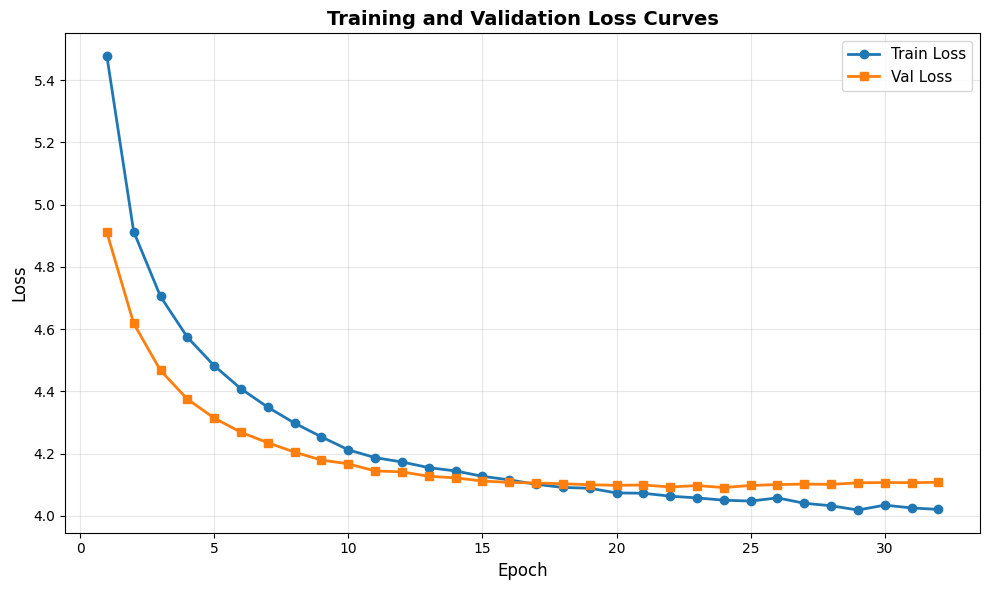

In [18]:
# ── Loss curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(results_df['Epoch'], results_df['Train Loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(results_df['Epoch'], results_df['Val Loss'],   label='Val Loss',   marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss',  fontsize=12)
plt.title('Training and Validation Loss Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, 'loss_curves.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f'Plot saved to: {plot_path}')
plt.show()

## BLEU-4 Evaluation on Validation Set

In [19]:
@torch.no_grad()
def beam_search(feature, beam_size=5, max_len=50):
    """
    feature : (49, 2048) CPU tensor for a single image.
    Returns : list of token strings (best caption, without <start>/<end>).
    """
    model.eval()
    enc  = feature.unsqueeze(0).to(device)
    h, c = model._init_hidden(enc)

    beams     = [([START_IDX], 0.0, h.clone(), c.clone())]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for seq, score, h, c in beams:
            tok     = torch.tensor([seq[-1]], device=device)
            emb     = model.embedding(tok)
            ctx, _  = model.attention(enc, h)
            lstm_in = torch.cat([emb, ctx], dim=1)
            h_new, c_new = model.lstm(lstm_in, (h, c))
            logits  = model.fc(model.dropout(h_new))

            logits[0, PAD_IDX] = -1e9
            log_probs           = torch.log_softmax(logits, dim=-1)
            topk_lp, topk_idx   = log_probs[0].topk(beam_size)

            for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                new_seq   = seq + [idx]
                new_score = score + lp
                if idx == END_IDX:
                    completed.append((new_seq, new_score))
                else:
                    new_beams.append((new_seq, new_score, h_new, c_new))

        new_beams.sort(key=lambda x: x[1], reverse=True)
        beams = new_beams[:beam_size]
        if not beams:
            break

    if not completed:
        completed = [(b[0], b[1]) for b in beams]

    best_seq, _ = max(completed, key=lambda x: x[1] / len(x[0]))
    tokens = [idx2word[i] for i in best_seq if i not in (START_IDX, END_IDX, PAD_IDX)]
    return tokens

print('Beam search ready.')

Beam search ready.


In [20]:
# ── Load best checkpoint then run BLEU-4 ─────────────────────────────────────
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
print(f'Loaded best model from epoch {ckpt["epoch"]}.')

smoothie  = SmoothingFunction().method4
refs_all, hyps_all = [], []

for img_name in tqdm(val_images, desc='BLEU eval'):
    if img_name not in all_features:
        continue
    feat = all_features[img_name]
    hyp  = beam_search(feat, beam_size=5)
    refs = [tokenize(c) for c in captions[img_name]]
    hyps_all.append(hyp)
    refs_all.append(refs)

bleu4 = corpus_bleu(refs_all, hyps_all, smoothing_function=smoothie)
print(f'\nValidation BLEU-4: {bleu4:.4f}')

Loaded best model from epoch 24.


BLEU eval: 100%|██████████| 810/810 [07:54<00:00,  1.71it/s]


Validation BLEU-4: 0.2214
